# Task description

Реалізувати:
- рекурентну нейронну мережу для прогнозування наступної ділянки:
  - в якості вхідних параметрів дані про ділянки між розладнанням
  - aрхітектура мережі з довгою короткочасною пам’яттю (LSTM).

# Init

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

from time_series import TimeSeries

In [55]:
class ChangepointSegmenter:
    def __init__(self, changepoints: list):
        self.changepoints = changepoints

    def split(self, series: np.ndarray) -> list[np.ndarray]:
        segments = []
        for i in range(len(self.changepoints) - 1):
            start = self.changepoints[i]
            end = self.changepoints[i + 1]
            if end > start:
                segments.append(np.array(series[start:end]))
        return segments


class LSTMPreprocessor:
    def __init__(self, window_size: int):
        self.window_size = window_size

    def generate_xy(self, segments: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
        x, y = [], []
        for segment in segments:
            if len(segment) <= self.window_size:
                continue
            for i in range(len(segment) - self.window_size):
                x.append(segment[i:i + self.window_size])
                y.append(segment[i + self.window_size])
        return np.array(x), np.array(y)


class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out


class Trainer:
    def __init__(self, model, lr=1e-3, epochs=50):
        self.model = model
        self.epochs = epochs
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.criterion = nn.MSELoss()

    def train(self, x, y):
        self.model.train()
        x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
        y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

        for epoch in range(self.epochs):
            output = self.model(x_tensor)
            loss = self.criterion(output, y_tensor)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()


class Forecaster:
    def __init__(self, model, window_size: int):
        self.model = model
        self.window_size = window_size

    def predict_next(self, segment: np.ndarray) -> float:
        self.model.eval()
        input_seq = torch.tensor(segment[-self.window_size:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
        with torch.no_grad():
            return self.model(input_seq).item()

    def predict_sequence(self, segment: np.ndarray, n_steps: int) -> list[float]:
        self.model.eval()
        history = list(segment[-self.window_size:])
        predictions = []
        for _ in range(n_steps):
            input_seq = torch.tensor(history[-self.window_size:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            with torch.no_grad():
                next_val = self.model(input_seq).item()
            predictions.append(next_val)
            history.append(next_val)
        return predictions

# Analyses

## Extract time series

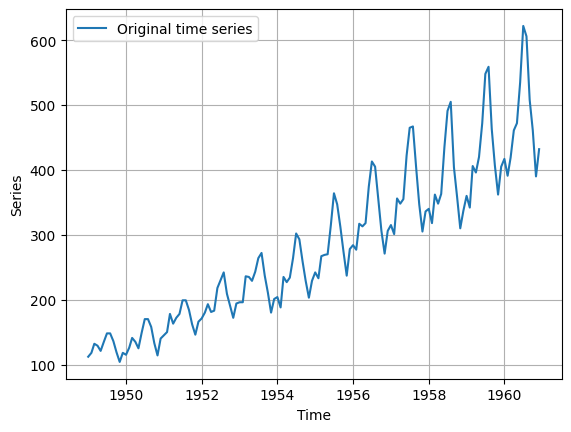

In [5]:
ts = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
ts.plot_series(label="Original time series")

# LLM

To get `checkpoint` run `lab_2`

In [6]:
%store -r checkpoint

In [56]:
def plot_last_segment_with_prediction(segment: np.ndarray, prediction: float, window_size: int):
    plt.figure(figsize=(10, 4))

    x_real = np.arange(len(segment))
    y_real = segment

    x_pred = len(segment)
    y_pred = prediction

    plt.plot(x_real, y_real, label="Остання реальна ділянка", color="green")

    plt.scatter(x_pred, y_pred, label=f"Прогноз: {prediction:.2f}", color="red", zorder=5)
    plt.axvline(x=x_pred - 0.5, color="gray", linestyle="--", alpha=0.5)

    plt.xlabel("Часовий індекс")
    plt.ylabel("Значення")
    plt.title(f"Прогноз наступного значення (вікно: {window_size})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Прогноз наступного значення: 0.565


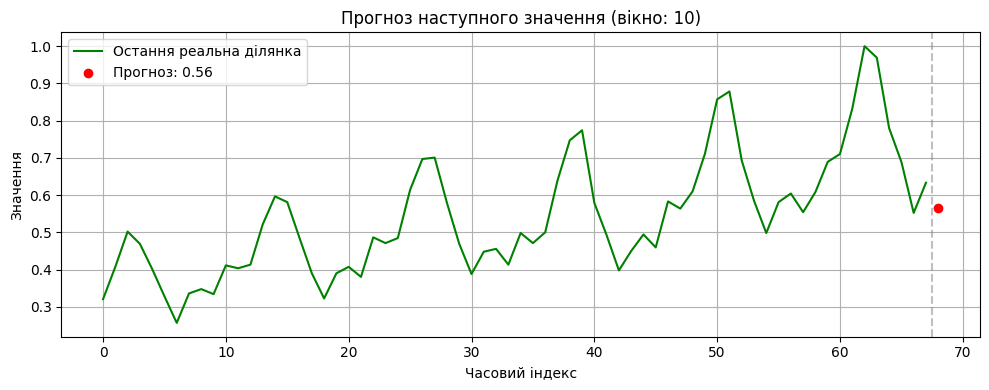

In [58]:
window_size = 10
changepoints = [0, int(checkpoint), len(ts.series)]

scaler = MinMaxScaler()
series = ts.series.to_numpy().reshape(-1, 1)
series_scaled = scaler.fit_transform(series).flatten()

segmenter = ChangepointSegmenter(changepoints)
segments = segmenter.split(series_scaled)
pre = LSTMPreprocessor(window_size=window_size)
x, y = pre.generate_xy(segments)

model = LSTMRegressor()
trainer = Trainer(model, lr=0.001, epochs=500)
trainer.train(x, y)

forecaster = Forecaster(model, window_size=window_size)
prediction = forecaster.predict_next(segments[-1])
print(f"Прогноз наступного значення: {prediction:.3f}")
plot_last_segment_with_prediction(segment=segments[-1], prediction=prediction, window_size=window_size)